In [1]:
#required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Dataset Medical Insurance Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
#Features and Targets
x = df.drop("charges", axis=1)
y = df["charges"]

In [6]:
#Categoriacal and Numerical Features
categorical = ["sex", "smoker", "region"]
numerical =["age", "children", "bmi"]

In [9]:
#Preprocessing Pipeline
preprocessor = ColumnTransformer([("onehot", OneHotEncoder(drop="first"), categorical)], remainder='passthrough')

In [10]:
#Linear Regression Pipeline
pipeline= Pipeline(steps=[("preprocessing", preprocessor), ("regression", LinearRegression())])

In [12]:
#Train and Tests sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
#Train the model
pipeline.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
#Predicting and Evaluation
y_pred = pipeline.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Model Evaluation:
Mean Squared Error (MSE): 33596915.85
R² Score: 0.78


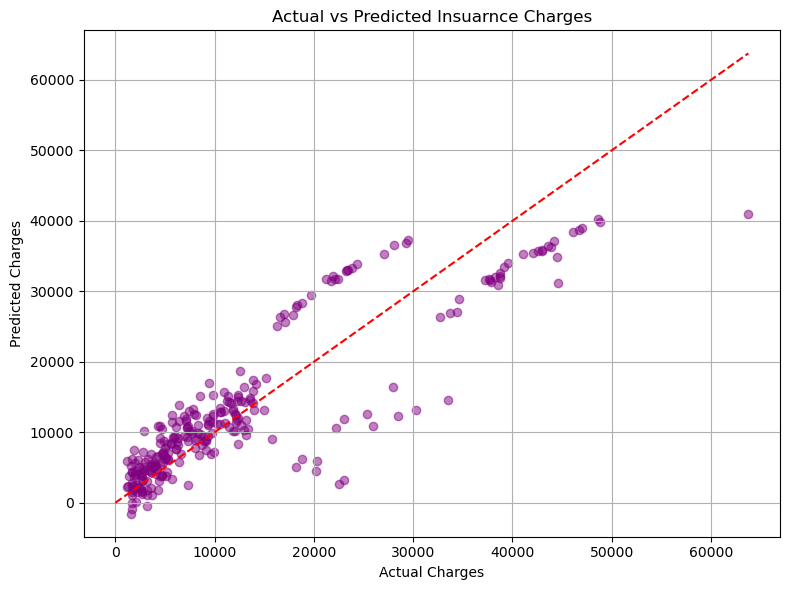

In [18]:
#Plot actual vs Predicted charges
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insuarnce Charges")
plt.grid(True)
plt.tight_layout()
plt.show()